# **Lab 6. LiDAR - 3D Point Cloud Combine & Real-Time Plane Segmentation**

**Hardware:** Livox MID-70 (3D LiDAR)  
**Platform:** Ubuntu 22.04 + ROS 2 Humble  
**Teamwork:** 4 Teams at all!!

## **Objectives**

* Connect the **Livox MID-70** to ROS 2 and visualize 3D point clouds in RViz2
* Capture multiple LiDAR snapshots from different positions in a room
* Implement the **ICP (Iterative Closest Point)** algorithm from scratch using NumPy
* Combine multiple point clouds into a single 3D map of the room
* Compare your ICP implementation with **Open3D**'s built-in ICP
* Detect **walls and floor** in real-time using **RANSAC** plane segmentation
* Publish segmentation results as colored markers in RViz2

## **Hardware**

* Livox MID-70 LiDAR sensor
* Livox Converter 2.0 (power + Ethernet interface)
* Conversion cable (M12 aviation connector to Converter 2.0)
* Ethernet cable (Converter 2.0 to PC)
* External power supply: 9–30 V via Converter 2.0
* Your laptop with an Ethernet port (or USB-Ethernet adapter)

### [Livox MID-70 Specs](https://www.livoxtech.com/mid-70)

| Parameter | Value |
|---|---|
| FOV | 70.4° circular |
| Range | 260 m (@ 80% reflectivity) |
| Point rate | 100,000 pts/s |
| Scan pattern | Non-repetitive (coverage grows over time) |
| Interface | Ethernet (UDP) |


> **Key feature:** Unlike spinning LiDARs (e.g. Velodyne), the MID-70 uses a non-repetitive scan pattern. This means that if you hold the LiDAR stationary for ~10–15 seconds, it accumulates a very dense point cloud covering the entire FOV - almost like taking a "photo" in 3D.

Cloud coverage example in 4 periods of time:


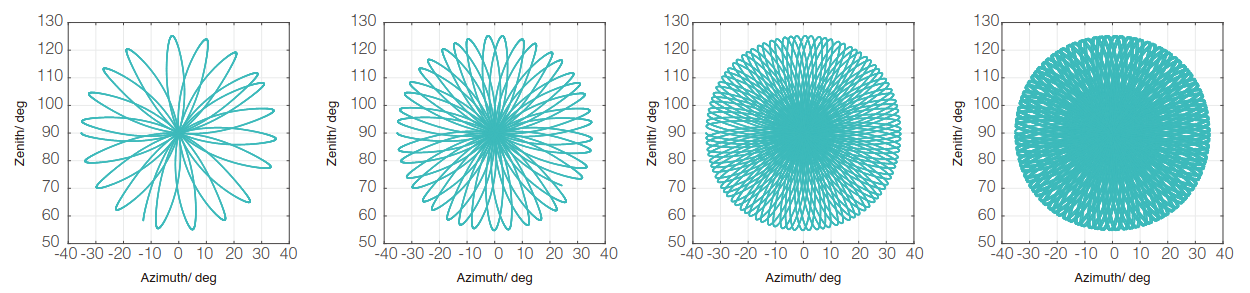

## **Software**

Special Docker container with:
* **ROS 2 Humble** (Desktop-Full)
* **Livox-SDK** (v1, for MID-70) + **livox_ros2_driver** (community fork for Humble)
* **Open3D** - point cloud processing and visualization
* **NumPy**, **SciPy** - for implementing ICP from scratch
* **RViz2** - real-time visualization

### Useful Links

* [Livox MID-70 User Manual (PDF)](https://terra-1-g.djicdn.com/65c028cd298f4669a7f0e40e50ba1131/Download/Mid-70/new/Livox%20Mid-70%20User%20Manual_EN_v1.2.pdf)
* [Livox-SDK (v1) GitHub](https://github.com/Livox-SDK/Livox-SDK)
* [livox_ros2_driver for Humble (community fork)](https://github.com/silolytics/livox_ros2_driver_humble)
* [Open3D ICP Tutorial](https://www.open3d.org/docs/release/tutorial/pipelines/icp_registration.html)
* [Open3D Plane Segmentation](https://www.open3d.org/docs/release/tutorial/geometry/pointcloud.html#Plane-segmentation)

## **Task 1. Hardware Connection & Driver Setup**

#### All following work should be in container:

### 1.1 Connect the MID-70

[User manual](https://terra-1-g.djicdn.com/65c028cd298f4669a7f0e40e50ba1131/Download/Mid-70/new/Livox%20Mid-70%20User%20Manual_EN_v1.2.pdf)

1. Connect the MID-70 to the **Livox Converter 2.0** via the conversion cable (M12 aviation connector)
2. Connect the Converter 2.0 to your PC via **Ethernet cable**
3. Connect the Converter 2.0 to the **external power supply** (9-30 V DC)
4. The MID-70 LED should start blinking and LiDAR starts buzzing - the sensor is booting

### 1.2 Configure the network

The MID-70 uses a **static IP** by default: `192.168.123.1XX` (where XX = last 2 digits of the serial number printed on the sensor body).

Set your PC's Ethernet interface to a static IP in the same subnet by your own or through special script in lab files:

```bash
sudo ROBOT_IP=<livox lidar ip> HOST_IP_CIDR=<your pc static ip in the same network, e.g: 192.168.123.10/24> ~/ros2_ws/src/set_livox_connection.sh
```

You should see something like:

`Done. You can now use this interface to talk to the Livox Mid-70`


> **Tip:** If you need to use Wi-Fi, the Ethernet and Wi-Fi interfaces can coexist on different subnets without conflict.


### 1.3 Configure the driver

Edit the JSON config file to match your sensor's broadcast code inside container:

```bash
nano ~/livox_ws/src/livox_ros2_driver_humble/livox_ros2_driver/config/livox_lidar_config.json
```

Set `"enable_connect"` to `true` with your own `lidar_config`. You can determine your lidar by `broadcast_code` which is consist of S/N and numver `1` at the end

Build pkgs:
```bash
cd ~/livox_ws/
colcon build
source install/setup.bash
cd ~/ros2_ws/
```

### 1.4 Launch and verify in RViz2

```bash
# Terminal 1: Launch the driver
ros2 launch livox_ros2_driver livox_lidar_rviz_launch.py
```

In RViz2 (in no data):
1. Set **Fixed Frame** to `livox_frame`
2. Add a **PointCloud2** display
3. Set the topic to `/livox/lidar`
4. Set **Size** to `0.01` and **Color Transformer** to `Intensity` or `FlatColor`

You should see a point cloud that gradually fills in the scene as the non-repetitive scan pattern covers the FOV.

> *tip:* try to increase `Decay Time` in `PointCloud2` menu

Check available topics:
```bash
ros2 topic list
ros2 topic hz /livox/lidar   # Should show ~10 Hz
```

**Checkpoint (report):** Screenshot of the live point cloud in RViz2.

---

## **Task 2. Build a 3D Map of the Room Using ICP**

### Overview

In this task, you will:
1. Capture 2+ LiDAR "snapshots" from different positions in the room
2. Implement **ICP from scratch** (NumPy + SciPy) and stitch the clouds together
3. Repeat the stitching using **Open3D's ICP** and compare the results
4. Publish the final combined point cloud to RViz2

### Why ICP?

The **Iterative Closest Point** algorithm finds the optimal rigid transformation (rotation + translation) that aligns one point cloud to another. It works by:
1. Finding the **nearest neighbor** in the target cloud for each point in the source cloud
2. Computing the **optimal rotation and translation** (using SVD) that minimizes the sum of squared distances
3. Applying the transformation and **repeating** until convergence

This is the foundational algorithm behind most 3D mapping and SLAM systems.

### 2.1 Capture LiDAR Snapshots

[rosbag docs](https://docs.ros.org/en/humble/Tutorials/Beginner-CLI-Tools/Recording-And-Playing-Back-Data/Recording-And-Playing-Back-Data.html)


For this task we use Ros2 bags. ROS Bag (rosbag) is a built-in ROS2 tool for recording and replaying messages from topics. It saves all messages (with precise timestamps) to a file, and can then play them back as if the sensor were running live.

---



Choose a room where **at least 2 walls** are visible from each position.

For each position (minimum **2 positions**):

1. Place the LiDAR on a stable surface (tripod recommended)
2. Wait **~10 seconds** with recording for the non-repetitive pattern to fill the FOV:

Record for ~10 seconds, then press `Ctrl+C`:
```bash
ros2 bag record -o snapshot_<paste number> /livox/lidar
```

Or use timeout to stop automatically:
```bash
timeout 10 ros2 bag record -o snapshot_<paste number> /livox/lidar
```

4. Move the LiDAR to the next position (translate by ~1–2 meters, try to keep some overlap near 40-60%)
5. Repeat for positions 2, 3

Verify your recording:
```bash
ros2 bag info snapshot_1/
```
Should show `/livox/lidar` with type `sensor_msgs/msg/PointCloud2` and ~100 messages for 10 seconds at 10 Hz

> **Important:** Ensure significant **overlap** between snapshots — at least 30% of the scene should be visible from both positions. Overlapping walls, corners, and furniture are the features ICP uses for alignment.

### 2.2 Extract point clouds from rosbags

Write a Python script (or ROS 2 node) that:
1. Reads a rosbag file
2. Accumulates all PointCloud2 messages from one snapshot into a single dense point cloud
3. Saves the result as a `.ply` file

Helpful code for converting `PointCloud2` to numpy:


In [9]:
import numpy as np
import struct
from pathlib import Path
from rosbags.typesys import Stores, get_typestore
from rosbags.highlevel import AnyReader
import open3d as o3d


def msg_to_numpy(msg):
    """Convert a deserialized PointCloud2 message to an Nx3 numpy array."""
    field_map = {f.name: f for f in msg.fields}
    if "x" not in field_map:
        return np.empty((0, 3))

    ox, oy, oz = field_map["x"].offset, field_map["y"].offset, field_map["z"].offset
    step = msg.point_step
    data = bytes(msg.data)
    n = msg.width * msg.height

    points = np.empty((n, 3), dtype=np.float32)
    for i in range(n):
        base = i * step
        points[i, 0] = struct.unpack_from("<f", data, base + ox)[0]
        points[i, 1] = struct.unpack_from("<f", data, base + oy)[0]
        points[i, 2] = struct.unpack_from("<f", data, base + oz)[0]

    valid = np.isfinite(points).all(axis=1) & (np.linalg.norm(points, axis=1) > 0.1)
    return points[valid].astype(np.float64)


def extract_bag(bag_path, topic="/livox/lidar"):
    """Read all PointCloud2 messages from a bag and return accumulated points."""
    typestore = get_typestore(Stores.ROS2_HUMBLE)
    all_points = []
    with AnyReader([Path(bag_path)], default_typestore=typestore) as reader:
        conns = [c for c in reader.connections if c.topic == topic]
        for conn, timestamp, rawdata in reader.messages(connections=conns):
            msg = reader.deserialize(rawdata, conn.msgtype)
            pts = msg_to_numpy(msg)
            if len(pts) > 0:
                all_points.append(pts)
    return np.vstack(all_points) if all_points else np.empty((0, 3))

# === Save as .ply ===

def save_cloud(points, filename):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    o3d.io.write_point_cloud(filename, pcd)
    print(f"Saved {len(points)} points to {filename}")

# If you want to work in ROS2 fully
# from sensor_msgs_py import point_cloud2
def pc2_to_numpy(msg):
    points = []
    for p in point_cloud2.read_points(msg, field_names=('x', 'y', 'z'), skip_nans=True):
        points.append([p[0], p[1], p[2]])
    return np.array(points, dtype=np.float64)

### 2.3 Preprocess the point clouds

Before running ICP, apply preprocessing to reduce noise and computation time:

```python
import open3d as o3d

pcd = o3d.io.read_point_cloud("snapshot_1.ply")

# Voxel Downsampling divides the entire 3D space into a uniform grid of small
# cubes (voxels) with a given side length (in this case 5 cm). All points that
# fall within the same voxel are replaced by a single point at their centroid.
# This reduces the number of points while preserving the overall
# geometric shape of the scene. Smaller voxel_size keeps more detail but is
# slower to process; larger values are faster but lose fine features.
pcd_down = pcd.voxel_down_sample(voxel_size=0.05)  # 5 cm voxels


# Statistical Outlier Removal identifies and removes isolated noisy points
# that  don't belong to any real surface. For each point, it computes the mean
# distance to its nb_neighbors (nearest neighbors, here 20). If that mean
# distance is more than std_ratio (standard deviations, here 2.0) above the
# global average, the point is considered an outlier and removed. This
# effectively cleans up stray points caused by reflections, dust, sensor noise,
# or multi-path interference - all of which are common with solid-state LiDARs
# like the MID-70.
pcd_clean, ind = pcd_down.remove_statistical_outlier(
    nb_neighbors=20, std_ratio=2.0)


# Normal Estimation computes a surface normal vector for each point by fitting
# a local plane to its neighborhood. The KDTreeSearchParamHybrid defines how
# neighbors are selected: it considers points within a radius of 10 cm and caps
# the count at max_nn=30, whichever is more restrictive. The resulting normals
# are essential for Point-to-Plane ICP, which uses the normal direction to
# constrain how each point should "slide" onto the target surface — this is
# what makes it converge significantly faster than the basic Point-to-Point variant.
pcd_clean.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))

print(f"Original: {len(pcd.points)} \n Processed: {len(pcd_clean.points)} points")
```

> *note:* A 10-second MID-70 capture at 100k pts/s yields ~1M points. Running ICP on the full cloud would take much time. Downsampling to ~50k points makes ICP run in seconds while preserving structural features.

### 2.4 Implement ICP from scratch (NumPy)

Implement the **point-to-point ICP** algorithm. Your implementation must include:

1. **Nearest neighbor search** using `scipy.spatial.KDTree`
2. **SVD-based optimal transformation** computation
3. **Iterative refinement** loop with convergence check

Links:

- [Original article of ICP](https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://graphics.stanford.edu/courses/cs164-09-spring/Handouts/paper_icp.pdf&ved=2ahUKEwjKhc_PxYuTAxUVR0EAHVHCANYQFnoECBoQAQ&usg=AOvVaw251UfODd_94GXfawVMAMkL)
- [Open3D docs](https://www.open3d.org/docs/latest/tutorial/pipelines/icp_registration.html)
- [Cool SVD-method description with animations by Arun, Huang & Blostein ;)](https://jingnanshi.com/blog/arun_method_for_3d_reg.html)
- [Article 'Least-Squares Fitting of Two 3-D Point Sets' by Arun, Huang & Blostein](https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://scispace.com/pdf/least-squares-fitting-of-two-3-d-point-sets-520ntlvg1b.pdf&ved=2ahUKEwj88cDmxouTAxUPUEEAHUkaJaoQFnoECB4QAQ&usg=AOvVaw0k2k4yz1isuw6vo20Kx8d1)
- [sensor_msgs/PointCloud2 Message](https://docs.ros.org/en/humble/p/sensor_msgs/msg/PointCloud2.html)
- [More detailed about sensor_msgs/PointCloud2 Message](https://medium.com/@tonyjacob_/pointcloud2-message-explained-853bd9907743)

Here is the skeleton - fill in the missing parts:

In [10]:
import numpy as np
from scipy.spatial import KDTree


def find_correspondences(source_points, target_tree, max_dist):
    """
    For each point in source, find the nearest neighbor in target.

    Args:
        source_points: (N, 3) array
        target_tree: KDTree built from target points
        max_dist: maximum correspondence distance

    Returns:
        src_idx: indices of source points with valid correspondences
        tgt_idx: indices of corresponding target points
    """
    distances, indices = target_tree.query(source_points)
    valid = distances <= max_dist
    src_idx = np.where(valid)[0]
    tgt_idx = indices[valid]
    return src_idx, tgt_idx


def compute_rigid_transform(src_points, tgt_points):
    """
    Compute optimal rotation R and translation t using SVD.
    Minimizes: sum ||R @ src_i + t - tgt_i||^2

    Args:
        src_points: (M, 3) matched source points
        tgt_points: (M, 3) matched target points

    Returns:
        R: (3, 3) rotation matrix
        t: (3,) translation vector
    """
    if src_points.shape[0] < 3:
        return np.eye(3), np.zeros(3)

    centroid_src = np.mean(src_points, axis=0)
    centroid_tgt = np.mean(tgt_points, axis=0)

    src_centered = src_points - centroid_src
    tgt_centered = tgt_points - centroid_tgt

    H = src_centered.T @ tgt_centered
    U, _, Vt = np.linalg.svd(H)

    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    t = centroid_tgt - R @ centroid_src
    return R, t


def icp(source, target, max_iterations=50, tolerance=1e-6, max_correspondence_dist=0.5):
    """
    Point-to-point ICP algorithm.

    Args:
        source: (N, 3) source point cloud
        target: (M, 3) target point cloud
        max_iterations: maximum number of ICP iterations
        tolerance: convergence threshold (change in mean error)
        max_correspondence_dist: max distance for valid correspondences

    Returns:
        T: (4, 4) final transformation matrix
        errors: list of mean errors per iteration
    """
    src = source.copy()
    target_tree = KDTree(target)

    T_total = np.eye(4)
    errors = []

    for _ in range(max_iterations):
        src_idx, tgt_idx = find_correspondences(src, target_tree, max_correspondence_dist)
        if len(src_idx) < 3:
            break

        src_corr = src[src_idx]
        tgt_corr = target[tgt_idx]

        R, t = compute_rigid_transform(src_corr, tgt_corr)

        src = (R @ src.T).T + t

        T_iter = np.eye(4)
        T_iter[:3, :3] = R
        T_iter[:3, 3] = t
        T_total = T_iter @ T_total

        residuals = np.linalg.norm(src_corr @ R.T + t - tgt_corr, axis=1)
        mean_error = float(np.mean(residuals))
        errors.append(mean_error)

        if len(errors) > 1 and abs(errors[-2] - errors[-1]) < tolerance:
            break

    return T_total, errors


# Usage:
# T, errors = icp(source_points, target_points)
# aligned_source = (T[:3, :3] @ source_points.T).T + T[:3, 3]

### helper functions

In [11]:
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d

# Resolve LAB06 path dynamically so the notebook works across machines.
def resolve_lab06_base():
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]

    # Case 1: running from workspace root where LAB06_Lidar is a subfolder.
    for p in candidates:
        candidate = p / "LAB06_Lidar"
        if (candidate / "snapshots").exists():
            return candidate

    # Case 2: running directly inside LAB06_Lidar.
    for p in candidates:
        if p.name == "LAB06_Lidar" and (p / "snapshots").exists():
            return p

    return None

BASE = resolve_lab06_base()
if BASE is None:
    raise FileNotFoundError(
        "Could not locate LAB06_Lidar/snapshots from current working directory. "
        "Open the notebook from the SensorsAndSensing workspace."
)
SNAP_DIR = BASE / "snapshots"

snapshot_files = [SNAP_DIR / "snapshot_1.ply", SNAP_DIR / "snapshot_2.ply", SNAP_DIR / "snapshot_4.ply"]

for p in snapshot_files:
    if not p.exists():
        raise FileNotFoundError(f"Missing snapshot file: {p}")

print("Using snapshots:")
for p in snapshot_files:
    print(" -", p)

# ---- Tunable preprocessing/registration parameters (lab-safe) ----
PREPROC = {
    "voxel_size": 0.02,
    "nb_neighbors": 20,
    "std_ratio": 4.0,
    "normal_radius": 0.10,
    "normal_max_nn": 40,
    "remove_outliers": True,
}

REG = {
    "single_scale_max_corr": 0.30,
    "single_scale_max_iter": 80,
    "single_scale_tol": 1e-6,
    "use_multiscale": True,
    "ms_voxels": [0.08, 0.04, 0.02],
    "ms_corr": [0.30, 0.16, 0.08],
    "ms_iters": [80, 60, 40],
    "eval_dist": 0.20,
    "global_voxel": 0.06,
    "global_dist_factor": 1.5,
    "refine_max_corr": 0.22,
    "min_fitness": 0.35,
    "max_inlier_rmse": 0.30,
    "max_eval_inlier_rmse": 0.20,
    "min_eval_overlap": 0.35,
    "allow_drop_bad_snapshot": True,
}

EXPORT = {
    "final_downsample_voxel": 0.015,
}

def preprocess_cloud(
    cloud,
    voxel_size=0.02,
    nb_neighbors=20,
    std_ratio=4.0,
    normal_radius=0.10,
    normal_max_nn=40,
    remove_outliers=True,
    estimate_normals=True,
):
    down = cloud.voxel_down_sample(voxel_size=voxel_size)
    if remove_outliers:
        down, _ = down.remove_statistical_outlier(
            nb_neighbors=nb_neighbors,
            std_ratio=std_ratio,
        )
    if estimate_normals:
        down.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamHybrid(
                radius=normal_radius,
                max_nn=normal_max_nn,
            )
        )
    return down

raw_clouds = [o3d.io.read_point_cloud(str(p)) for p in snapshot_files]
proc_clouds = [
    preprocess_cloud(
        c,
        voxel_size=PREPROC["voxel_size"],
        nb_neighbors=PREPROC["nb_neighbors"],
        std_ratio=PREPROC["std_ratio"],
        normal_radius=PREPROC["normal_radius"],
        normal_max_nn=PREPROC["normal_max_nn"],
        remove_outliers=PREPROC["remove_outliers"],
    )
    for c in raw_clouds
]
points_np = [np.asarray(c.points) for c in proc_clouds]

for p, raw, clean in zip(snapshot_files, raw_clouds, proc_clouds):
    ratio = (len(clean.points) / max(1, len(raw.points))) * 100.0
    print(f"{p.stem}: raw={len(raw.points):,}  processed={len(clean.points):,}  keep={ratio:.1f}%")

print("\nPREPROC:", PREPROC)
print("REG:", REG)
print("EXPORT:", EXPORT)

Using snapshots:
 - /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/SensorsAndSensing/LAB06_Lidar/snapshots/snapshot_1.ply
 - /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/SensorsAndSensing/LAB06_Lidar/snapshots/snapshot_2.ply
 - /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/SensorsAndSensing/LAB06_Lidar/snapshots/snapshot_4.ply
snapshot_1: raw=973,251  processed=250,467  keep=25.7%
snapshot_2: raw=982,045  processed=322,876  keep=32.9%
snapshot_4: raw=983,892  processed=339,075  keep=34.5%

PREPROC: {'voxel_size': 0.02, 'nb_neighbors': 20, 'std_ratio': 4.0, 'normal_radius': 0.1, 'normal_max_nn': 40, 'remove_outliers': True}
REG: {'single_scale_max_corr': 0.3, 'single_scale_max_iter': 80, 'single_scale_tol': 1e-06, 'use_multiscale': True, 'ms_voxels': [0.08, 0.04, 0.02], 'ms_corr': [0.3, 0.16, 0.08], 'ms_iters': [80, 60, 40], 'eval_dist': 0.2, 'global_voxel': 0.06, 'global_dist_factor': 1.5, 'refine_max_corr': 0.22, 'min_fitness': 0.35, 'max_inlier_

In [12]:
def run_custom_icp(source_np, target_np, max_corr=0.30, max_iter=80, tol=1e-6):
    t0 = time.perf_counter()
    T, errs = icp(
        source_np,
        target_np,
        max_iterations=max_iter,
        tolerance=tol,
        max_correspondence_dist=max_corr,
    )
    dt = time.perf_counter() - t0
    rmse = errs[-1] if errs else float("nan")
    return T, errs, rmse, dt

def evaluate_transform(source_pcd, target_pcd, T, eval_dist=0.20):
    src_tmp = o3d.geometry.PointCloud(source_pcd)
    src_tmp.transform(T)
    d = np.asarray(src_tmp.compute_point_cloud_distance(target_pcd))
    if d.size == 0:
        return {
            "rmse_all": float("inf"),
            "overlap": 0.0,
            "rmse_inlier": float("inf"),
            "p90_inlier": float("inf"),
        }

    rmse_all = float(np.sqrt(np.mean(d**2)))
    inliers = d[d < float(eval_dist)]
    overlap = float(inliers.size / d.size)
    if inliers.size == 0:
        rmse_inlier = float("inf")
        p90_inlier = float("inf")
    else:
        rmse_inlier = float(np.sqrt(np.mean(inliers**2)))
        p90_inlier = float(np.percentile(inliers, 90))

    return {
        "rmse_all": rmse_all,
        "overlap": overlap,
        "rmse_inlier": rmse_inlier,
        "p90_inlier": p90_inlier,
    }

def global_init_and_refine(source_pcd, target_pcd, cfg):
    gv = float(cfg["global_voxel"])
    src_g = source_pcd.voxel_down_sample(gv)
    tgt_g = target_pcd.voxel_down_sample(gv)

    nr = gv * 2.0
    src_g.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=nr, max_nn=50)
    )
    tgt_g.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=nr, max_nn=50)
    )

    src_f = o3d.pipelines.registration.compute_fpfh_feature(
        src_g,
        o3d.geometry.KDTreeSearchParamHybrid(radius=gv * 5.0, max_nn=100),
    )
    tgt_f = o3d.pipelines.registration.compute_fpfh_feature(
        tgt_g,
        o3d.geometry.KDTreeSearchParamHybrid(radius=gv * 5.0, max_nn=100),
    )

    dist_th = gv * float(cfg["global_dist_factor"])
    t0 = time.perf_counter()
    ransac = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
        src_g,
        tgt_g,
        src_f,
        tgt_f,
        mutual_filter=True,
        max_correspondence_distance=dist_th,
        estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
        ransac_n=4,
        checkers=[
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.9),
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(dist_th),
        ],
        criteria=o3d.pipelines.registration.RANSACConvergenceCriteria(100000, 0.999),
    )

    src_r = o3d.geometry.PointCloud(source_pcd)
    tgt_r = o3d.geometry.PointCloud(target_pcd)
    nr_r = max(PREPROC["normal_radius"], float(cfg["refine_max_corr"]) * 0.8)
    src_r.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=nr_r, max_nn=50)
    )
    tgt_r.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=nr_r, max_nn=50)
    )

    refine = o3d.pipelines.registration.registration_icp(
        src_r,
        tgt_r,
        max_correspondence_distance=float(cfg["refine_max_corr"]),
        init=ransac.transformation,
        estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane(),
        criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=int(cfg["single_scale_max_iter"])),
    )
    dt = time.perf_counter() - t0

    ev = evaluate_transform(
        source_pcd,
        target_pcd,
        refine.transformation,
        eval_dist=float(cfg["eval_dist"]),
    )

    result = {
        "name": "global+icp",
        "T": refine.transformation,
        "time": dt,
        "inlier_rmse": float(refine.inlier_rmse),
        "fitness": float(refine.fitness),
        "eval_rmse_all": float(ev["rmse_all"]),
        "eval_overlap": float(ev["overlap"]),
        "eval_inlier_rmse": float(ev["rmse_inlier"]),
        "eval_p90": float(ev["p90_inlier"]),
    }
    return result

def run_single_icp_candidate(source_pcd, target_pcd, cfg):
    src = o3d.geometry.PointCloud(source_pcd)
    tgt = o3d.geometry.PointCloud(target_pcd)
    src.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=PREPROC["normal_radius"], max_nn=50)
    )
    tgt.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=PREPROC["normal_radius"], max_nn=50)
    )

    t0 = time.perf_counter()
    res = o3d.pipelines.registration.registration_icp(
        src,
        tgt,
        max_correspondence_distance=float(cfg["single_scale_max_corr"]),
        init=np.eye(4),
        estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane(),
        criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=int(cfg["single_scale_max_iter"])),
    )
    dt = time.perf_counter() - t0

    ev = evaluate_transform(
        source_pcd,
        target_pcd,
        res.transformation,
        eval_dist=float(cfg["eval_dist"]),
    )

    return {
        "name": "single",
        "T": res.transformation,
        "time": dt,
        "inlier_rmse": float(res.inlier_rmse),
        "fitness": float(res.fitness),
        "eval_rmse_all": float(ev["rmse_all"]),
        "eval_overlap": float(ev["overlap"]),
        "eval_inlier_rmse": float(ev["rmse_inlier"]),
        "eval_p90": float(ev["p90_inlier"]),
    }

def run_multiscale_candidate(source_pcd, target_pcd, cfg):
    T = np.eye(4)
    last_res = None
    t0 = time.perf_counter()

    for v, c, it in zip(cfg["ms_voxels"], cfg["ms_corr"], cfg["ms_iters"]):
        src = source_pcd.voxel_down_sample(float(v))
        tgt = target_pcd.voxel_down_sample(float(v))
        nr = max(2.0 * float(v), 0.08)
        src.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=nr, max_nn=50)
        )
        tgt.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=nr, max_nn=50)
        )

        last_res = o3d.pipelines.registration.registration_icp(
            src,
            tgt,
            max_correspondence_distance=float(c),
            init=T,
            estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane(),
            criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=int(it)),
        )
        T = last_res.transformation

    dt = time.perf_counter() - t0
    ev = evaluate_transform(
        source_pcd,
        target_pcd,
        T,
        eval_dist=float(cfg["eval_dist"]),
    )

    return {
        "name": "multiscale",
        "T": T,
        "time": dt,
        "inlier_rmse": float(last_res.inlier_rmse) if last_res is not None else float("inf"),
        "fitness": float(last_res.fitness) if last_res is not None else 0.0,
        "eval_rmse_all": float(ev["rmse_all"]),
        "eval_overlap": float(ev["overlap"]),
        "eval_inlier_rmse": float(ev["rmse_inlier"]),
        "eval_p90": float(ev["p90_inlier"]),
    }

def candidate_score(c):
    return (
        (3.0 * c["fitness"])
        + (3.0 * c["eval_overlap"])
        - (2.0 * c["inlier_rmse"])
        - (2.0 * c["eval_inlier_rmse"])
        - (0.5 * c["eval_p90"])
    )

def candidate_is_acceptable(c, cfg):
    return (
        np.isfinite(c["inlier_rmse"])
        and np.isfinite(c["eval_inlier_rmse"])
        and c["fitness"] >= float(cfg["min_fitness"])
        and c["inlier_rmse"] <= float(cfg["max_inlier_rmse"])
        and c["eval_inlier_rmse"] <= float(cfg["max_eval_inlier_rmse"])
        and c["eval_overlap"] >= float(cfg["min_eval_overlap"])
    )

def choose_transform(source_pcd, target_pcd, cfg):
    candidates = []
    candidates.append(run_single_icp_candidate(source_pcd, target_pcd, cfg))

    if cfg["use_multiscale"]:
        candidates.append(run_multiscale_candidate(source_pcd, target_pcd, cfg))

    candidates.append(global_init_and_refine(source_pcd, target_pcd, cfg))

    for c in candidates:
        c["score"] = candidate_score(c)
        c["ok"] = candidate_is_acceptable(c, cfg)

    valid = [c for c in candidates if c["ok"]]
    chosen = max(valid, key=lambda x: x["score"]) if valid else max(candidates, key=lambda x: x["score"])
    return chosen, candidates

# Register snapshot_2 -> snapshot_1
src2 = points_np[1]
tgt1 = points_np[0]
T_custom_21, errs_custom_21, rmse_custom_21, t_custom_21 = run_custom_icp(
    src2,
    tgt1,
    max_corr=REG["single_scale_max_corr"],
    max_iter=REG["single_scale_max_iter"],
    tol=REG["single_scale_tol"],
)

best_21, cand_21 = choose_transform(proc_clouds[1], proc_clouds[0], REG)
T_best_21 = best_21["T"]
method_21 = best_21["name"]
rmse_best_21 = best_21["eval_inlier_rmse"]
fit_best_21 = best_21["eval_overlap"]
t_best_21 = best_21["time"]

print("Registration snapshot_2 -> snapshot_1")
print(f"Custom ICP: iters={len(errs_custom_21):3d}  RMSE~{rmse_custom_21:.4f}  time={t_custom_21:.3f}s")
for c in cand_21:
    tag = "OK" if c["ok"] else "BAD"
    print(
        f"{c['name']:>10}: inlier_RMSE={c['inlier_rmse']:.4f} fit={c['fitness']:.4f} "
        f"eval_inlier_RMSE={c['eval_inlier_rmse']:.4f} eval_overlap={c['eval_overlap']:.4f} "
        f"eval_p90={c['eval_p90']:.4f} score={c['score']:.4f} [{tag}] time={c['time']:.3f}s"
    )
print(f"Selected 2->1: method={method_21} eval_inlier_RMSE~{rmse_best_21:.4f} eval_overlap~{fit_best_21:.4f} time={t_best_21:.3f}s")

/var/folders/x2/kn9h64511ybfdf1yhc51xlnh0000gn/T/ipykernel_74027/1718203056.py:47: RuntimeWarning: divide by zero encountered in matmul
  H = src_centered.T @ tgt_centered
/var/folders/x2/kn9h64511ybfdf1yhc51xlnh0000gn/T/ipykernel_74027/1718203056.py:47: RuntimeWarning: overflow encountered in matmul
  H = src_centered.T @ tgt_centered
/var/folders/x2/kn9h64511ybfdf1yhc51xlnh0000gn/T/ipykernel_74027/1718203056.py:47: RuntimeWarning: invalid value encountered in matmul
  H = src_centered.T @ tgt_centered
/var/folders/x2/kn9h64511ybfdf1yhc51xlnh0000gn/T/ipykernel_74027/1718203056.py:90: RuntimeWarning: divide by zero encountered in matmul
  src = (R @ src.T).T + t
/var/folders/x2/kn9h64511ybfdf1yhc51xlnh0000gn/T/ipykernel_74027/1718203056.py:90: RuntimeWarning: overflow encountered in matmul
  src = (R @ src.T).T + t
/var/folders/x2/kn9h64511ybfdf1yhc51xlnh0000gn/T/ipykernel_74027/1718203056.py:90: RuntimeWarning: invalid value encountered in matmul
  src = (R @ src.T).T + t
/var/folders

Registration snapshot_2 -> snapshot_1
Custom ICP: iters= 80  RMSE~0.0763  time=235.424s
    single: inlier_RMSE=0.0413 fit=0.8480 eval_inlier_RMSE=0.0288 eval_overlap=0.8360 eval_p90=0.0326 score=4.8955 [OK] time=4.521s
multiscale: inlier_RMSE=0.0206 fit=0.8125 eval_inlier_RMSE=0.0288 eval_overlap=0.8358 eval_p90=0.0327 score=4.8299 [OK] time=1.941s
global+icp: inlier_RMSE=0.0309 fit=0.8384 eval_inlier_RMSE=0.0288 eval_overlap=0.8359 eval_p90=0.0326 score=4.8874 [OK] time=6.946s
Selected 2->1: method=single eval_inlier_RMSE~0.0288 eval_overlap~0.8360 time=4.521s


In [13]:
# Build full map with quality-gated transforms.
# If snapshot_4 alignment is poor, optionally exclude it to avoid shifted final map.


best_42, cand_42 = choose_transform(proc_clouds[2], proc_clouds[1], REG)
T_best_42 = best_42["T"]
method_42 = best_42["name"]
rmse_best_42 = best_42["eval_inlier_rmse"]
fit_best_42 = best_42["eval_overlap"]
ok_42 = best_42["ok"]

best_41_direct, cand_41_direct = choose_transform(proc_clouds[2], proc_clouds[0], REG)
T_41_direct = best_41_direct["T"]
rmse_41_direct = best_41_direct["eval_inlier_rmse"]
fit_41_direct = best_41_direct["eval_overlap"]
ok_41_direct = best_41_direct["ok"]

# Chained path 4->2->1 only if both legs are acceptable
ok_chain = bool(best_21["ok"] and ok_42)
if ok_chain:
    T_41_chain = T_best_21 @ T_best_42
    ev_chain = evaluate_transform(
        proc_clouds[2],
        proc_clouds[0],
        T_41_chain,
        eval_dist=REG["eval_dist"],
    )
    rmse_41_chain = float(ev_chain["rmse_inlier"])
    fit_41_chain = float(ev_chain["overlap"])
    ok_41_chain = (
        np.isfinite(rmse_41_chain)
        and (rmse_41_chain <= float(REG["max_eval_inlier_rmse"]) * 1.20)
        and (fit_41_chain >= float(REG["min_eval_overlap"]) * 0.90)
    )
else:
    T_41_chain = np.eye(4)
    rmse_41_chain = float("inf")
    fit_41_chain = 0.0
    ok_41_chain = False

# Choose final 4->1 strategy
if ok_41_chain and (rmse_41_chain <= rmse_41_direct * 1.10):
    T_41 = T_41_chain
    path_41 = "chain 4->2->1"
    rmse_41 = rmse_41_chain
    fit_41 = fit_41_chain
    use_snapshot4 = True
elif ok_41_direct:
    T_41 = T_41_direct
    path_41 = f"direct 4->1 ({best_41_direct['name']})"
    rmse_41 = rmse_41_direct
    fit_41 = fit_41_direct
    use_snapshot4 = True
else:
    T_41 = np.eye(4)
    path_41 = "rejected (quality gate)"
    rmse_41 = float("inf")
    fit_41 = 0.0
    use_snapshot4 = not bool(REG["allow_drop_bad_snapshot"])

# Apply transforms to RAW clouds to preserve detail
cloud1 = o3d.geometry.PointCloud(raw_clouds[0])
cloud2 = o3d.geometry.PointCloud(raw_clouds[1])
cloud4 = o3d.geometry.PointCloud(raw_clouds[2])
cloud2.transform(T_best_21)
if use_snapshot4:
    cloud4.transform(T_41)

colors = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
cloud1.paint_uniform_color(colors[0])
cloud2.paint_uniform_color(colors[1])
cloud4.paint_uniform_color(colors[2])

combined = o3d.geometry.PointCloud()
combined += cloud1
combined += cloud2
if use_snapshot4:
    combined += cloud4

# Export maps
out_map = BASE / "room_map_3d.ply"
out_colored = BASE / "room_map_3d_colored.ply"
out_map_tuned = BASE / "room_map_3d_tuned.ply"
out_colored_tuned = BASE / "room_map_3d_colored_tuned.ply"

combined_ds = combined.voxel_down_sample(float(EXPORT["final_downsample_voxel"]))

o3d.io.write_point_cloud(str(out_map), combined_ds)
o3d.io.write_point_cloud(str(out_colored), combined)
o3d.io.write_point_cloud(str(out_map_tuned), combined_ds)
o3d.io.write_point_cloud(str(out_colored_tuned), combined)

print(f"Saved merged map to: {out_map}")
print(f"Saved colored merged map to: {out_colored}")
print(f"Saved tuned merged map to: {out_map_tuned}")
print(f"Saved tuned colored map to: {out_colored_tuned}")
print(f"Total merged points: full={len(combined.points):,}  downsampled={len(combined_ds.points):,}")

print("\nCandidates 4->2:")
for c in cand_42:
    tag = "OK" if c["ok"] else "BAD"
    print(
        f"{c['name']:>10}: inlier_RMSE={c['inlier_rmse']:.4f} fit={c['fitness']:.4f} "
        f"eval_inlier_RMSE={c['eval_inlier_rmse']:.4f} eval_overlap={c['eval_overlap']:.4f} "
        f"eval_p90={c['eval_p90']:.4f} score={c['score']:.4f} [{tag}]"
    )

print("\nCandidates 4->1 direct:")
for c in cand_41_direct:
    tag = "OK" if c["ok"] else "BAD"
    print(
        f"{c['name']:>10}: inlier_RMSE={c['inlier_rmse']:.4f} fit={c['fitness']:.4f} "
        f"eval_inlier_RMSE={c['eval_inlier_rmse']:.4f} eval_overlap={c['eval_overlap']:.4f} "
        f"eval_p90={c['eval_p90']:.4f} score={c['score']:.4f} [{tag}]"
    )

print(f"\nSelected 4->2 method: {method_42}  eval_inlier_RMSE~{rmse_best_42:.4f} eval_overlap~{fit_best_42:.4f}")
print(f"Selected 4->1 path:   {path_41}")
if use_snapshot4:
    print(f"Final 4->1 quality:   eval_inlier_RMSE~{rmse_41:.4f} eval_overlap~{fit_41:.4f}")
else:
    print("Snapshot_4 excluded from merged map due to failed quality gate.")

SHOW_VIS = False
if SHOW_VIS:
    o3d.visualization.draw_geometries(
        [combined],
        window_name="Merged room map (quality-gated)",
    )

Saved merged map to: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/SensorsAndSensing/LAB06_Lidar/room_map_3d.ply
Saved colored merged map to: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/SensorsAndSensing/LAB06_Lidar/room_map_3d_colored.ply
Saved tuned merged map to: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/SensorsAndSensing/LAB06_Lidar/room_map_3d_tuned.ply
Saved tuned colored map to: /Users/anashamrouni/Documents/InnopolisUniversity/Bachelor/SensorsAndSensing/LAB06_Lidar/room_map_3d_colored_tuned.ply
Total merged points: full=2,939,188  downsampled=951,511

Candidates 4->2:
    single: inlier_RMSE=0.1288 fit=0.4153 eval_inlier_RMSE=0.0828 eval_overlap=0.3426 eval_p90=0.1574 score=1.7718 [BAD]
multiscale: inlier_RMSE=0.0389 fit=0.1858 eval_inlier_RMSE=0.0918 eval_overlap=0.3158 eval_p90=0.1637 score=1.1615 [BAD]
global+icp: inlier_RMSE=0.0331 fit=0.7977 eval_inlier_RMSE=0.0308 eval_overlap=0.7950 eval_p90=0.0363 score=4.6322 [OK]

Candidate

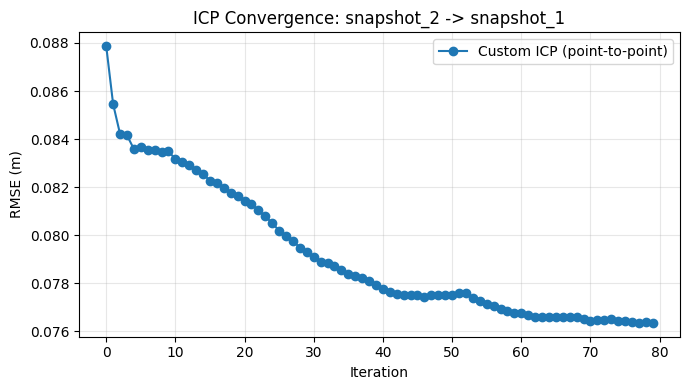


=== Comparison table (snapshot_2 -> snapshot_1) ===
Custom ICP (preprocessed):      iter= 80, RMSE~0.0763, fitness=n/a,   time=235.424s
Open3D P2P (preprocessed):      iter=n/a,               RMSE=0.1122, fitness=0.5021, time=4.982s
Open3D P2L (preprocessed):      iter=n/a,               RMSE=0.0413, fitness=0.8480, time=4.223s

=== Sensitivity (poor 45° initial guess) ===
Open3D P2P bad init: RMSE=0.1343, fitness=0.1682, time=6.769s
Open3D P2L bad init: RMSE=0.1313, fitness=0.1516, time=7.165s

Tip for report: Point-to-Plane usually converges faster because it minimizes point-to-surface distance along local normals,
which provides stronger geometric constraints than raw point-to-point Euclidean distance.


In [14]:
# Report-ready metrics + plots

def run_open3d_icp(source_pcd, target_pcd, point_to_plane=False, init=None):
    src = o3d.geometry.PointCloud(source_pcd)
    tgt = o3d.geometry.PointCloud(target_pcd)

    if init is None:
        init = np.eye(4)

    max_corr = float(REG["single_scale_max_corr"] if "single_scale_max_corr" in REG else 0.30)
    max_iter = int(REG["single_scale_max_iter"] if "single_scale_max_iter" in REG else 80)

    if point_to_plane:
        nr = float(PREPROC["normal_radius"] if "normal_radius" in PREPROC else 0.10)
        src.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=nr, max_nn=50)
        )
        tgt.estimate_normals(
            search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=nr, max_nn=50)
        )
        estimation = o3d.pipelines.registration.TransformationEstimationPointToPlane()
    else:
        estimation = o3d.pipelines.registration.TransformationEstimationPointToPoint()

    t0 = time.perf_counter()
    res = o3d.pipelines.registration.registration_icp(
        src,
        tgt,
        max_correspondence_distance=max_corr,
        init=init,
        estimation_method=estimation,
        criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=max_iter),
    )
    dt = time.perf_counter() - t0
    return res, dt

# Open3D baselines on preprocessed clouds
res_p2p_21, t_p2p_21 = run_open3d_icp(proc_clouds[1], proc_clouds[0], point_to_plane=False, init=np.eye(4))
res_p2l_21, t_p2l_21 = run_open3d_icp(proc_clouds[1], proc_clouds[0], point_to_plane=True, init=np.eye(4))

# 1) Convergence plot for custom ICP
plt.figure(figsize=(7, 4))
plt.plot(errs_custom_21, marker="o", label="Custom ICP (point-to-point)")
plt.xlabel("Iteration")
plt.ylabel("RMSE (m)")
plt.title("ICP Convergence: snapshot_2 -> snapshot_1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Sensitivity experiment: poor initial guess (45 deg yaw) for Open3D
angle = np.deg2rad(45)
Rz = np.array([
    [np.cos(angle), -np.sin(angle), 0, 0],
    [np.sin(angle),  np.cos(angle), 0, 0],
    [0,              0,             1, 0],
    [0,              0,             0, 1],
], dtype=float)

res_p2p_bad_init, t_p2p_bad_init = run_open3d_icp(proc_clouds[1], proc_clouds[0], point_to_plane=False, init=Rz)
res_p2l_bad_init, t_p2l_bad_init = run_open3d_icp(proc_clouds[1], proc_clouds[0], point_to_plane=True, init=Rz)

# 3) Performance-style summary
print("\n=== Comparison table (snapshot_2 -> snapshot_1) ===")
print(f"Custom ICP (preprocessed):      iter={len(errs_custom_21):3d}, RMSE~{rmse_custom_21:.4f}, fitness=n/a,   time={t_custom_21:.3f}s")
print(f"Open3D P2P (preprocessed):      iter=n/a,               RMSE={res_p2p_21.inlier_rmse:.4f}, fitness={res_p2p_21.fitness:.4f}, time={t_p2p_21:.3f}s")
print(f"Open3D P2L (preprocessed):      iter=n/a,               RMSE={res_p2l_21.inlier_rmse:.4f}, fitness={res_p2l_21.fitness:.4f}, time={t_p2l_21:.3f}s")

print("\n=== Sensitivity (poor 45° initial guess) ===")
print(f"Open3D P2P bad init: RMSE={res_p2p_bad_init.inlier_rmse:.4f}, fitness={res_p2p_bad_init.fitness:.4f}, time={t_p2p_bad_init:.3f}s")
print(f"Open3D P2L bad init: RMSE={res_p2l_bad_init.inlier_rmse:.4f}, fitness={res_p2l_bad_init.fitness:.4f}, time={t_p2l_bad_init:.3f}s")

print("\nTip for report: Point-to-Plane usually converges faster because it minimizes point-to-surface distance along local normals,")
print("which provides stronger geometric constraints than raw point-to-point Euclidean distance.")

### 2.5 Register point clouds using Open3D ICP

Now repeat the registration using Open3D. Compare **two variants**:

```python
import open3d as o3d
import numpy as np

source = o3d.io.read_point_cloud("snapshot_1_processed.ply")
target = o3d.io.read_point_cloud("snapshot_2_processed.ply")

# Variant 1: Point-to-Point ICP
result_p2p = o3d.pipelines.registration.registration_icp(
    source, target,
    max_correspondence_distance=0.5,
    init=np.eye(4),
    estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint())

print(f"Point-to-Point: fitness={result_p2p.fitness:.4f}, RMSE={result_p2p.inlier_rmse:.4f}")

# Variant 2: Point-to-Plane ICP (requires normals)
result_p2l = o3d.pipelines.registration.registration_icp(
    source, target,
    max_correspondence_distance=0.5,
    init=np.eye(4),
    estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane())

print(f"Point-to-Plane: fitness={result_p2l.fitness:.4f}, RMSE={result_p2l.inlier_rmse:.4f}")
```

> **fitness** = ratio of inlier correspondences / total source points. Values close to 1.0 are good.

> **inlier_rmse** = RMSE of inlier correspondences in meters. Lower is better.

### 2.6 Stitch all snapshots into a single 3D map

Register clouds **pairwise** and accumulate transformations:


Color each cloud differently (e.g., red/green/blue) and merge:

```python
colors = [[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 1, 0]]  # RGB
combined = o3d.geometry.PointCloud()

for i, cloud in enumerate(aligned_clouds):
    cloud.paint_uniform_color(colors[i % len(colors)])
    combined += cloud

o3d.visualization.draw_geometries([combined])
o3d.io.write_point_cloud("room_map_3d.ply", combined)
```

### 2.7 Publish the combined map in RViz2

Write a simple ROS 2 node that:
1. Loads the combined `.ply` file
2. Publishes it as a `sensor_msgs/PointCloud2` message on topic `/map_3d`
3. Uses `livox_frame` or `map` as the `frame_id`

Visualize in RViz2 with **Color Transformer set to RGB8** to see the color-coded origins.

**Checkpoint (report):**
* Screenshot of the combined 3D map in RViz2 (color-coded by position)
* Comparison table: Your ICP vs. Open3D Point-to-Point vs. Open3D Point-to-Plane
  * Metrics: number of iterations to converge, RMSE, fitness, execution time
* Convergence plot: RMSE vs. iteration number for each method

---

## **Task 3. Real-Time Wall & Floor Detection with RANSAC**

### Overview

In this task, you will create a **ROS 2 node** that:
1. Subscribes to the **live** point cloud from the Livox MID-70
2. Applies **iterative RANSAC** plane segmentation to detect multiple planes
3. Classifies each plane as **floor** or **wall** based on its normal vector
4. Publishes colored markers in RViz2 for each detected surface
5. Publishes the **remaining (non-planar) points** as a separate "objects" topic

### How RANSAC plane fitting works

**RANSAC (Random Sample Consensus)** detects a plane in a noisy point cloud by:
1. Randomly selecting **3 points** and computing the plane equation `ax + by + cz + d = 0`
2. Counting how many other points lie within a **distance threshold** from this plane (inliers)
3. Repeating for many random samples
4. Keeping the plane model with the **most inliers**

To detect multiple planes, we run RANSAC iteratively: find the largest plane - remove its inliers - repeat.

### ✅ Task 3 implementation completed (LAB06 isolated)

Implemented package location:

- `/home/nasta/Documents/GitHub/SensorsAndSensing/LAB06_Lidar/ros2_ws/src/lidar_lab`
- Node: `lidar_lab/plane_detector_node.py`
- Launch: `launch/plane_detector.launch.py`

Build and run (only inside LAB06):

```bash
cd /home/nasta/Documents/GitHub/SensorsAndSensing/LAB06_Lidar/ros2_ws
colcon build --packages-select lidar_lab
source install/setup.bash
ros2 launch lidar_lab plane_detector.launch.py
```

RViz2 checks:

- Add `PointCloud2` for `/planes/floor`
- Add `PointCloud2` for `/planes/walls`
- Add `PointCloud2` for `/planes/objects`
- Add `MarkerArray` for `/planes/markers`

Task 3 deliverables now supported:

- Iterative RANSAC multi-plane extraction
- Wall/floor classification from plane normals
- Colored plane markers + floor/wall/object point cloud topics
- Per-frame timing logs (`downsample`, `ransac`, `publish`, `total`) for Question 6

### 3.1 Node structure

Create a ROS 2 Python package:

```bash
cd ~/ros2_ws/src
ros2 pkg create lidar_lab --build-type ament_python --license Apache-2.0 \
  --dependencies rclpy sensor_msgs visualization_msgs std_msgs geometry_msgs
```

Create the node file: `lidar_lab/lidar_lab/plane_detector_node.py`

**Node interface:**

Subscribe:
 - `/livox/lidar` (`sensor_msgs/PointCloud2`) - Raw LiDAR data

Publish:
 -  `/planes/markers` (`visualization_msgs/MarkerArray`) - Colored plane markers
 - `/planes/floor` (`sensor_msgs/PointCloud2`) - Floor inlier points
 - `/planes/walls` (`sensor_msgs/PointCloud2`) - Wall inlier points
 - `/planes/objects` (`sensor_msgs/PointCloud2`) - Remaining (non-planar) points

Parameters (recommended):


 - `voxel_size` (0.05): Downsampling voxel size (m)
 - `distance_threshold` (0.02): RANSAC inlier distance (m)
 - `ransac_n` (3): Points to sample per iteration
 - `num_iterations` (1000): RANSAC iterations per plane
 - `max_planes` (5): Max planes to extract
 - `min_inlier_ratio` (0.05): Stop when plane has < 5% of remaining points

## **Questions**

Answer the following questions in your report:

1. **ICP convergence.** How many iterations did your ICP implementation need to converge? How does this compare to Open3D's Point-to-Point and Point-to-Plane ICP? Plot the RMSE vs. iteration curves for all three. Why does Point-to-Plane typically converge faster?

2. **ICP sensitivity.** What happens to ICP quality when you:
   - Reduce the overlap between snapshots (e.g., move the LiDAR 3+ meters between positions)?
   - Skip the preprocessing step (no downsampling, no outlier removal)?
   - Provide a poor initial guess (e.g., initial rotation of 45°)?
   
   Try at least one of these experiments and report the results.

4. **RANSAC reliability.** Run your RANSAC 10 times on the same point cloud. Do you always get the same planes? Why or why not? What parameter has the most impact on repeatability?

5. **Plane classification.** Which walls in the room did the algorithm detect successfully? Which did it miss, and why? (Consider: occlusion, distance, angle of incidence, material reflectivity.)

6. **Real-time performance.** What is the bottleneck in your real-time pipeline? Measure the time for each step (downsample, RANSAC, publish) and identify where optimization would help most.